# Chapter 2. 지도 학습

In [17]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy as sp
import IPython
import sklearn
import mglearn

print('Python 버전:', sys.version)
print('numpy 버전:', np.__version__)
print('pandas 버전:', pd.__version__)
print('matplotlib 버전:', matplotlib.__version__)
print('SciFy 버전:', sp.__version__)
print('IPython 버전:', IPython.__version__)
print('scikit-learn 버전:', sklearn.__version__)

from sklearn.model_selection import train_test_split
#plt.rc('font', family="Apple SD Gothic Neo")

Python 버전: 3.9.12 (main, Apr  5 2022, 06:56:58) 
[GCC 7.5.0]
numpy 버전: 1.21.5
pandas 버전: 1.4.2
matplotlib 버전: 3.5.1
SciFy 버전: 1.7.3
IPython 버전: 8.2.0
scikit-learn 버전: 1.0.2


## 2.3 지도 학습 알고리즘

### 2.3.5 결정 트리 (decision tree)
- ***분류와 회귀 문제에 널리 사용하는 모델, 결정에 다다르기 위해 예/아니오 질문을 이어 나가면서 학습***
- 결정 트리의 **노드(node)는 질문이나 정답**을 담고 있고, 특히 **마지막 노드를 리프(leaf)라고** 함, 에지(edge)는 질문의 답과 다음 질문을 연결
- 결정 트리를 학습한다는 것은 정답에 가장 빨리 도달하는 예/아니오 질문 목록을 학습한다는 뜻, **이런 질문들은 테스트**라고 함, 연속적인 데이터에 적용할 테스트는 **"특성 i는 값 a보다 큰가? 와 같은 형태임** 
- ***DecisionTreeRegressor(그리고 모든 다른 트리 기반 회귀 모델)는 외삽(extrapolation), 즉 훈련 데이터의 범위 밖의 포인트에 대하여 예측을 할 수 없음***

- **장단점**
> - 모델 시각화를 통해 비교적 작은 트리일 때 이해하기 좋음
> - **데이터 스케일에 구애 받지 않으므로 특성의 정규화나 표준화 같은 전처리 필요 없음**, 특성의 스케일이 서로 다르거나 이진 특성과 연속 특성이 혼합되어 있을 때도 잘 작동
> - **가지치기를 사용하더라도 과적합 우려 있어 일반화 성능이 떨어짐 -> 앙상블 방법을 통해 단일 결정 트리의 대안으로 사용**

- **매개변수**
> - 사전 가지치기 : **max_depth** (트리의 최대 깊이), **max_leaf_nodes** (리프 노드의 최대 개수), **min_samples_leaf** (리프 노드가 되기 위한 최소한의 샘플 개수), **min_samples_split** (노드가 분기할 수 있는 최소 샘플 개수), **min_impurity_decrease** (분할로 얻어질 불순도 감소 최소값 지정)
> - ***criterion* 매개변수로 분할 기준을 지정** : **Classifier의 경우 지니 불순도인 'gini(기본값)'와 엔트로피 불순도인 'entropy'를 지정, Regressor는 'squared_error(기본값)', 'absolute_error'를 사용**
> - DecisionTreeRegressor를 기반으로 하는 RandomForestRegressor, ExtraTreesRegressor, GradientBoostingClassifier, GradientBoostingRegressor의 criterion 매개변수 값도 동일하게 변경

#### <U>*결정 트리 만들기*</U>
- **루트 노드(root node) :** 트리 구조 상 맨위 노드, 전체 데이터 셋을 나타냄
- **순수 노드(pure node) :** 결정 트리를 통해 분할된 영역에서 타깃 하나로만 이뤄진 리프 노드를 나타냄
- **분류**에 대한 문제인 경우 **새로운 데이터 포인트가 특성을 분할한 영역들 중 어디에 놓이는지를 확인** -> 영역의 타깃 값 중 다수(순수 노드라면 하나)인 것을 예측 결과로 도출
- **회귀** 문제일 경우 새로운 데이터 포인트에 **해당하는 리프 노드의 훈련 데이터 평균 값**이 해당 데이터 포인트의 예측 출력 값이 됨

#### <U>*결정 트리의 복잡도 제어하기*</U>
- 일반적으로 트리 만들기를 모든 리프 노드가 순수 노드가 될 때까지 진행하면 모델이 매우 복잡해지고 훈련 데이터에 과대적합함 -> 결정 경계가 클래스의 포인트들에서 멀리 떨어진 이상치(outlier) 하나에 너무 민감하게 됨

- 과대 적합을 막는 전략
> - **사전 가지치기(pre-pruning) :** 트리 생성을 일찍 중단 -> **트리의 최대 깊이(max_depth)나 리프의 최대 개수(max_leaf_nodes)를 제한하거나, 또는 노드가 분할하기 위한 포인트의 최소 개수(min_samples_split)를 지정**
> - **사후 가지치기(post-pruning) : 트리를 만든 후 데이터 포인트가 적은 노드를 삭제하거나 병합하는 전략**, Scikit-learn에서 지원 X, 0.22 버전에서 비용 복잡도 기반의 사후 가지치기를 위한 ccp_alpha 매개변수 추가

In [9]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, 
                                                    stratify=cancer.target, random_state=42)

tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)

print('훈련 세트 정확도 : {:.3f}'.format(tree.score(X_train, y_train)))
print('테스트 세트 정확도 : {:.3f}'.format(tree.score(X_test, y_test)))

훈련 세트 정확도 : 1.000
테스트 세트 정확도 : 0.937


In [10]:
tree_md4 = DecisionTreeClassifier(max_depth=4, random_state=0)
tree_md4.fit(X_train, y_train)
print('훈련 세트 정확도 : {:.3f}'.format(tree_md4.score(X_train, y_train)))
print('테스트 세트 정확도 : {:.3f}'.format(tree_md4.score(X_test, y_test)))

훈련 세트 정확도 : 0.988
테스트 세트 정확도 : 0.951


- 트리 깊이를 제한하면 과대적합이 줄어듦에 따라 훈련 세트의 정확도를 떨어뜨리지만 테스트 세트의 성능은 개선됨

#### <U>*결정 트리 분석*</U>
- 트리 모듈의 ***export_graphviz*** 함수를 이용해 그래프 저장용 텍스트 파일 포멧인 .dot 파일을 만들 수 있고, 이를 graphviz 모듈을 사용해 시각화 할 수 있음
- 아래 예시처럼 새로 추가된 ***plot_tree()* 함수를 사용하면 .dot 파일을 만들지 않고 바로 트리를 시각화 할 수 있음**

In [5]:
# 1. graphviz 모듈 이용
from sklearn.tree import export_graphviz
export_graphviz(tree, out_file='tree.dot', class_names=['Negative','Positive'],
                feature_names=cancer.feature_names, impurity=False, filled=True)

import graphviz
with open('tree.dot') as f:
    dot_graph = f.read()
display(graphviz.Source(dot_graph))

ModuleNotFoundError: No module named 'graphviz'

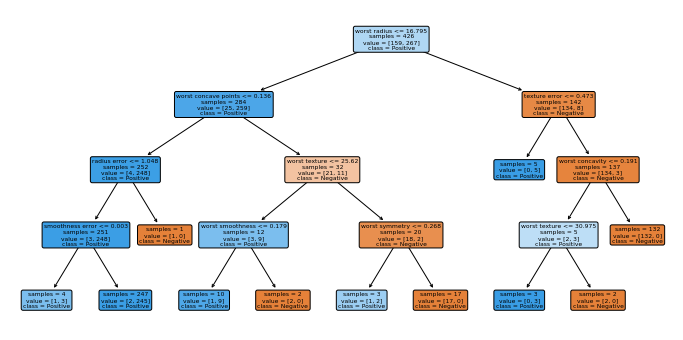

In [11]:
# 2. plot_tree 함수 이용
from sklearn.tree import plot_tree
plt.figure(figsize=(12, 6))
plot_tree(tree_md4, class_names=['Negative', 'Positive'], feature_names=cancer.feature_names, 
          impurity=False, filled=True, rounded=True, fontsize=6)
plt.show()

#### <U>*트리의 특성 중요도*</U>
- 트리가 어떻게 작동하는지 요약하는 속성 사용 가능
- 가장 널리 사용되는 속성은 **트리를 만드는 결정에 각 특성이 얼마나 중요한지를 평가하는 특성 중요도(feature importance)임**
- 특성 중요도는 **0(전혀 사용 x) ~ 1(완벽하게 타깃 클래스 예측) 사이의 값**을 가짐, 특성 중요도의 전체 합은 1임
    > - 특성 중요도가 낮다고 해서 유용하지 않다는 것이 아님을 주의, **단지 그 트리가 특성을 선택하지 않았을 뿐이며 다른 특성이 동일한 정보를 지니고 있어서 일수도 있음**
    > - **특성 중요도가 어떤 클래스를 지지하는지는 알 수 없음**, "worst radius"가 중요하다고 알려주지만 높은 지름이 양성을 의미하는지 악성을 의미하는지는 알 수 없음

In [12]:
print('특성 중요도:\n', tree.feature_importances_)

특성 중요도:
 [0.         0.00752597 0.         0.         0.00903116 0.
 0.00752597 0.         0.         0.         0.00975731 0.04630969
 0.         0.00238745 0.00231135 0.         0.         0.
 0.         0.00668975 0.69546322 0.05383211 0.         0.01354675
 0.         0.         0.01740312 0.11684357 0.01137258 0.        ]


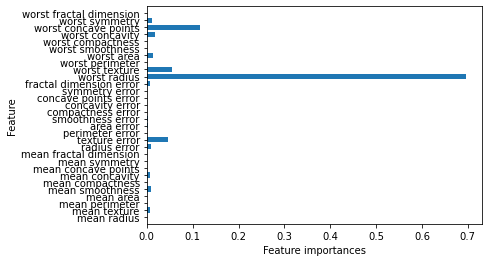

In [13]:
## 따로 저장해서 추후 개인 툴로 활용해보기
def plot_feature_importances_cancer(model):
    n_features = cancer.data.shape[1]
    plt.barh(np.arange(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), cancer.feature_names)
    plt.xlabel('Feature importances')
    plt.ylabel('Feature')
    plt.ylim(-1, n_features)

    
plot_feature_importances_cancer(tree)


> - ***트리 기반 회귀 모델의 외삽 리스크 검토***

Text(0, 0.5, 'price ($/Mbyte)')

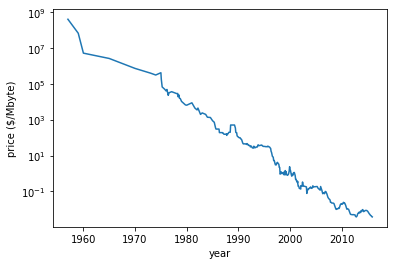

In [10]:
ram_prices = pd.read_csv("data/ram_price.csv")

plt.yticks(fontname='Arial')
plt.semilogy(ram_prices.date, ram_prices.price)
plt.xlabel('year')
plt.ylabel('price ($/Mbyte)')

In [11]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

# 2000년 이전을 훈련 데이터로, 2000년 이후를 테스트 데이터로 만듦
data_train = ram_prices[ram_prices.date<2000]
data_test = ram_prices[ram_prices.date>=2000]

# 가격 예측을 위해 날짜 특성만을 고려
X_train = data_train.date.to_numpy()[:, np.newaxis]
# 데이터와 타깃 사이의 관계를 간단하게 만들기 위해 로그 스케일로 변경
y_train = np.log(data_train.price)

tree = DecisionTreeRegressor().fit(X_train, y_train)
linear_reg = LinearRegression().fit(X_train, y_train)

# 예측은 전체 기간에 대해서 수행
X_all = ram_prices.date.to_numpy()[:, np.newaxis]

pred_tree = tree.predict(X_all)
pred_lr = linear_reg.predict(X_all)

# 예측한 값의 로그 스케일을 되돌림
price_tree = np.exp(pred_tree)
price_lr = np.exp(pred_lr)

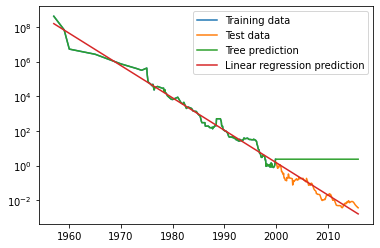

In [12]:
plt.semilogy(data_train.date, data_train.price, label='Training data')
plt.semilogy(data_test.date, data_test.price, label='Test data')
plt.semilogy(ram_prices.date, price_tree, label='Tree prediction')
plt.semilogy(ram_prices.date, price_lr, label='Linear regression prediction')
plt.legend()

- 트리 복잡도에 제한을 두지 않아서 전체 데이터셋을 모두 기억하므로 훈련 데이터를 완벽하게 예측하나, **데이터 범위 밖으로 나가면 단순히 마지막 포인트를 이용해 예측함**

> - ***n_features_in_*** : 변환기를 포함하여 모든 추정기 클래스에 fit 메서드에 입력된 특성 개수를 저장하는 속성
> - ***feature_names_in_*** : pandas 데이터프레임의 열 이름을 저장

In [14]:
tree.fit(data_train[['date']], y_train)
print('특성 개수:', tree.n_features_in_)
print('특성 이름:', tree.feature_names_in_)

특성 개수: 1
특성 이름: ['date']


### 2.3.6 결정 트리의 앙상블
- 앙상블(ensemble)은 여러 머신러닝 모델을 연결하여 더 강력한 모델을 만드는 기법임, 과적합 방지 및 더 높은 성능의 결과를 도출하도록 여러 모델을 활용
- **대표적 앙상블 기법 : Voting, Bagging(Bootstrap Aggregating), Boosting**
> - Voting : 회귀에서는 예측값의 평균 사용, 분류에서는 'hard'-직접투표(다수결), 'soft'-간접투표(확률의 평균) 사용
> - Bagging(Bootstrap + Aggregating) : 복원 추출을 통해 랜덤 추출한 데이터를 생성하고, 각 데이터를 모델 학습하여 결합한 후, 학습된 모델의 예측 변수를 활용하여 최종 모델을 생성하는 방법
> - Boosting : 여러 개의 약한 모델(weak laerner)을 수정하여 강한 모델(strong learner)을 만드는 방법, 독립적인 모델을 합산하여 산출하기보다는 기존의 모델을 개선시키는 방향의 앙상블 기법
- **의사결정 트리와 앙상블 기법을 활용한 다양한 모델**
> - **랜덤 포레스트 : 변수와 특성에 대한 Bagging**
> - **부스팅 계열 모델 : 부스팅시 모델 개선 방향에 따라 Ada Boost, Gradient Boosting, XGBoost, LGBM, CatBoos**

#### <U>*랜덤 포레스트*</U>
- 기본적으로 조금씩 다른 여러 결정 트리의 묶음
- **잘 작동하되 서로 다른 방향으로 과적합된 트리를 많이 만들면 그 결과를 평균냄으로써 과적합 양을 줄일 수 있음**
- 트리들이 달라지도록 트리 생성 시 무작위성을 주입 **1. 데이터 포인트를 무작위로 선택, 2. 분할 테스트에서 특성을 무작위로 선택**
- 이러한 무작위성은 알고리즘이 **가능성 있는 많은 경우를 고려할 수 있도록 하므로**, 그 결과 랜덤 포레스트가 단일 트리보다 **더 넓은 시각으로 데이터**를 바라보게 함

- **매개변수**
> - ***n_esitimators*** : 생성할 트리의 개수 (기본값 100), **"가용한 시간과 메모리만큼 많이" 만드는 것이 좋음**
> - 부트스트랩 관련 : ***bootstrap*** (진행여부, 기본값 True), ***max_samples*** (부트스트랩 샘플 개수 지정, 기본 값은 None으로 훈련 샘플 개수만큼 추출, 원하는 샘플 개수를 지정하거나 훈련 샘플 개수의 비율 0~1사이 지정 가능)
> - **특성 선택(분기 무작위성) : *max_features*** (3. '결정 트리 생성' 참고)
    >> - 각 트리가 얼마나 무작위가 될지 결정, **일반적으로 기본 값을 쓰는 것이 좋음**
    >> - **분류에서의 기본 값은 *max_features = sqrt(n_features),* 회귀는 *max_features = n_features***
> - ***n_jobs***(기본값 1) 매개변수를 이용하여 사용할 코어 수 지정 가능, **-1 설정 시 모든 코어 사용**
> - 사전 가지치기(기본 결정 트리와 동일) : **max_depth** (트리의 최대 깊이), **max_leaf_nodes** (리프 노드의 최대 개수), **min_samples_leaf** (리프 노드가 되기 위한 최소한의 샘플 개수), **min_samples_split** (노드가 분기할 수 있는 최소 샘플 개수), **min_impurity_decrease** (분할로 얻어질 불순도 감소 최소값 지정), **ccp_alpha**
> - ***max_features*나 *max_leaf_nodes* 매개변수를 추가하면 가끔 성능이 향상되기도 함**, 자원과 시간을 줄일 수도 있음

- **장단점**
> - **랜덤 포레스트는 기본 매개변수 셋팅에서도 개개의 트리보다는 덜 과적합되고 훨씬 좋은 결과를 만들 가능성이 높음**
> - 일반적으로 랜덤 포레스트에서 제공하는 특성 중요도가 하나의 트리에서 제공하는 것보다 더 신뢰할만 함 (각 트리의 특성 중요도를 취합하여 계산)
> - **(주의)** 다른 *random_state*를 지정하면 (또는 값을 별도로 지정하지 않으면) 전혀 다른 모델 생성, 랜덤 포레스트의 트리가 많을수록 *random_state* 값의 변화에 따른 변동이 줄어듦 -> **만약 같은 결과를 만들어야 한다면 *random_state* 값을 고정**
> - 선형 모델보다 많은 메모리를 사용하여 훈련과 예측이 느릴 수 있음, 속도와 메모리 사용이 중요한 애플리케이션이라면 선형 모델이 적합

#### <U>*랜덤 포레스트 구축*</U>
1. 생성할 트리의 개수 선정 : ***n_estimators***
2. **각 트리들 독립적으로 만들기 위한 무작위 선택**
    > - 트리를 만들기 위해 먼저 데이터의 부트스트랩 샘플(bootstrap) 생성
    > - **n_samples개의 데이터 포인트 중에서 무작위로 데이터를 n_samples 횟수만큼 반복 추출**
    > - 이 데이터셋은 원래 데이터셋 크기와 같지만, 한 샘플이 반복 추출되거나 어떤 데이터 포인트는 누락될 수 있음(대략 1/3 정도)
3. 결정 트리 생성
    > - 각 노드에서 전체 특성을 대상으로 최선의 테스트를 찾는 것이 아니고 각 노드에서 후보 특성을 무작위로 선택한 후 이 중에서 최선의 테스트를 검토함
    > - ***max_features*를 n_features로 설정(max)하면** 트리의 각 분기에서 모든 특성을 고려하므로 무작위성 해제(bootstrap에 의한 무작위성은 유지)
    > - ***max_features*를 1로 설정(min)하면** 분기는 테스트할 특성을 검토(평가)하지 않고, 그냥 무작위로 선택한 특성의 임계값만 검토
    > - ***max_features*를 높이면 트리들은 매우 비슷해지고 가장 두드러진 특성을 이용해 데이터에 맞춤**
    > - ***max_features*를 낮추면 트리들은 많이 달라지고 각 트리는 데이터에 맞추기 위해 깊이가 깊어짐**
4. 예측 도출
    > - 먼저 알고리즘이 모델에 있는 모든 트리의 예측을 생성
    > - **회귀의 경우에는 이 예측들을 평균하여 최종 예측을 생성**
    > - 분류의 경우에는 약한 투표 전략 사용 -> 각 알고리즘이 가능성 있는 출력 레이블의 확률을 제공함으로써 간접적인 예측 진행 -> **트리들이 예측한 확률을 평균내어 가장 높은 확률을 가진 클래스를 최종 예측값으로 도출** 

#### <U>*랜덤 포레스트 분석*</U>
> - 'two moon' 데이터셋을 가지고 트리 5개로 구성된 랜덤 포레스트 모델 검토

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=100, noise=0.25, random_state=3)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

forest = RandomForestClassifier(n_estimators=5, random_state=2)
forest.fit(X_train, y_train)

RandomForestClassifier(n_estimators=5, random_state=2)

> - 랜덤 포레스트 안에 만들어진 트리는 ***estimators_*** 속성에 저장, 각 트리에서 학습한 결정 경계와 이를 취합한 경계를 시각화

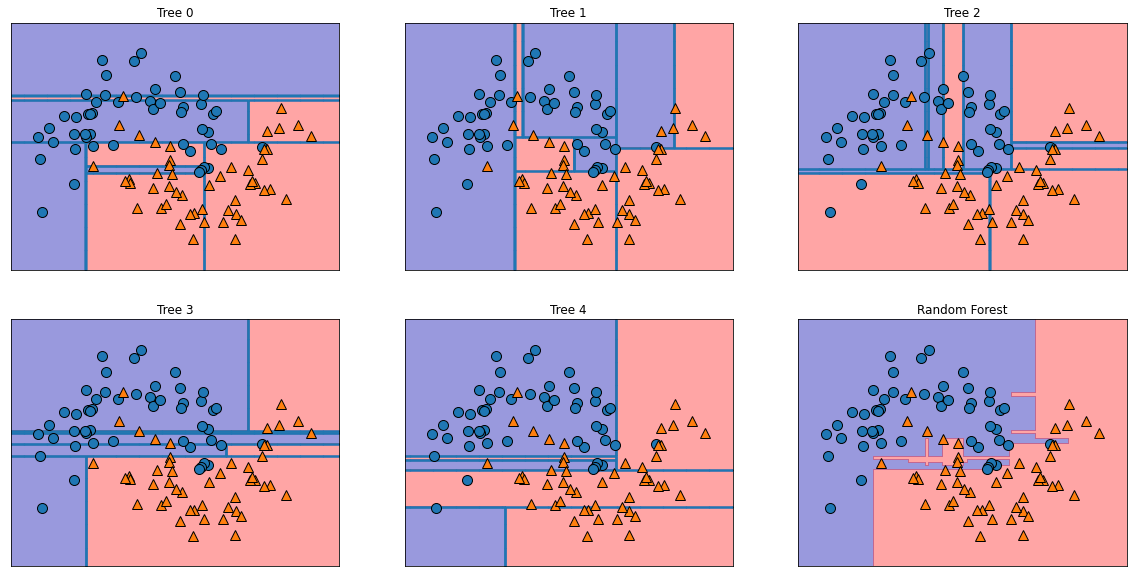

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(20,10))
for i, (ax, tree) in enumerate(zip(axes.ravel(), forest.estimators_)):
    ax.set_title("Tree {}".format(i))
    mglearn.plots.plot_tree_partition(X, y, tree, ax=ax)
    
mglearn.plots.plot_2d_separator(forest, X, fill=True, ax=axes[-1,-1], alpha=0.4)
axes[-1,-1].set_title('Random Forest')
mglearn.discrete_scatter(X[:,0], X[:,1], y)

> - 유방안 데이터셋에 100개의 트리로 이뤄진 랜덤 포레스트 적용

In [7]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)
forest = RandomForestClassifier(n_estimators=100, random_state=0)
forest.fit(X_train, y_train)

print('훈련 세트 정확도: {:.3f}'.format(forest.score(X_train, y_train)))
print('테스트 세트 정확도: {:.3f}'.format(forest.score(X_test, y_test)))

훈련 세트 정확도: 1.000
테스트 세트 정확도: 0.972


In [14]:
def plot_feature_importances_cancer(model):
    n_features = cancer.data.shape[1]
    plt.barh(np.arange(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), cancer.feature_names)
    plt.xlabel('Feature importances')
    plt.ylabel('Feature')
    plt.ylim(-1, n_features)

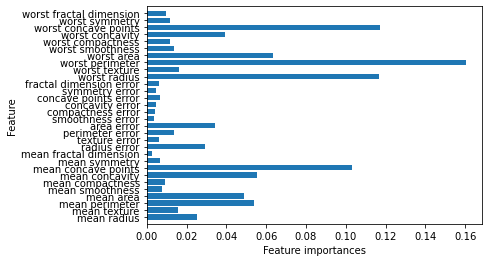

In [15]:
plot_feature_importances_cancer(forest)

#### <U>*그레디언트 부스팅 회귀 트리*</U>
- 회귀와 분류 모두에 사용 가능, **DecisionTreeRegressor**을 사용하여 알고리즘 구현 
- **이전 트리의 오차를 보완하는 방식으로 순차적으로 트리 생성**, 약한 학습기(weak learner)을 많이 연결
    > - 이를 위해 손실함수를 정의하고 경사 하강법(gradient descent)을 사용하여 다음에 추가될 트리가 예측해야 할 값을 보정
- 각각의 트리는 데이터의 일부에 대해서만 예측을 잘 수행하므로 **트리가 많이 추가될수록 성능 향상됨**
- 비슷한 종류의 데이터에서 그레디언트 부스팅과 랜덤 포레스트 둘 다 잘 작동, **일반적으로 더 안정적인 랜덤 포레스트를 먼저 적용하고 예측 시간이 중요해지거나 모델에서 마지막 성능까지 쥐어짜야 할 때 그레디언트스 부스팅 사용**
- 대규모 머신러닝 문제에 그레디언트 부스팅을 적용하려면 xgboost 패키지와 파이썬 인터페이스를 검토해 보는 것 추천

- **매개변수**
> - **중요 성능 매개변수**
    >> - ***learning_rate* : 이전 트리의 오차를 얼마나 강하게 보정할지 제어**, 학습률이 크면 보정을 강하게 하여 복잡한 모델 생성
    >> - ***n_estimators*** : 값을 올리면 앙상블에 트리가 더 많이 추가되어 모델의 복잡도가 커지고 훈련 세트에서의 실수를 바로 잡을 기회가 증가함
    >> - 두 매개변수는 서로 깊게 연관되어 *learning_rate*를 낮추면 비슷한 복잡도의 모델을 만들기 위해서 더 많은 트리를 추가해야함
    >> - *n_estimators*가 클수록 좋은 랜덤 포레스트와 달리 그레디언트 부스팅에서는 모델이 복잡해지고 과적합 우려가 큼
    >> - **일반적인 관례는 가용한 시간과 메모리 한도에서 *n_estimators를* 맞추고 나서 적절한 *learning_rate를* 찾음**
> - 사전 가지치기(기본 결정 트리와 동일) : **max_depth** (트리의 최대 깊이, 통상 매우 작게 설정하며 5보다 깊어지지 않게 함, 기본값 3), **max_leaf_nodes** (리프 노드의 최대 개수), **min_samples_leaf** (리프 노드가 되기 위한 최소한의 샘플 개수), **min_samples_split** (노드가 분기할 수 있는 최소 샘플 개수), **min_impurity_decrease** (분할로 얻어질 불순도 감소 최소값 지정), **ccp_alpha**
> - ***subsample* : 트리를 훈련하는데 사용할 훈련 샘플의 비율(0~1) 지정**
    >> - 기본 값 1이면 전체 샘플 사용, 0보다 작게 설정하면 랜덤하게 선택된 일부 샘플로 개별 트리를 훈련하는 확률적 그레디언트 부스팅이 되며, 분산이 줄고 편향이 증가
    >> - 선택되지 않은 샘플 (out-of-bag, OOB)로 훈련된 트리의 손실 값을 계산하고 이전 트리와 현재 트리의 손실 차이를 oob_imporvement_ 속성에 저장
> - ***max_features* : 트리 분할에 사용할 특성 개수를 지정**, 기본 값은 None으로 전체 특성을 사용, 'sqrt'는 특성 개수의 제곱근, 'log2'는 log2(특성개수)을 사용, 특성 개수를 직접 지정하거나 0~1 사이로 비율을 지정할 수도 있음
> - ***loss* : 훈련에 사용할 손실함수를 지정**
    >> - **Classifier**의 기본 값은 로지스틱 손실을 의미하는 **'log_loss'**
    >> - **Regressor**에서는 제곱 오차와 절댓값 오차를 의미하는 **'squared_error'(기본), 'absolute_error'** 사용
> - ***n_iter_no_change, validation_fraction* : 조기 종료를 위한 매개변수들**, 훈련 데이터에서 *validation_fraction*(기본값 1) 비율만큼 검증 데이터로 사용하여 *n_iter_no_change* 반복 동안 검증 점수가 향상되지 않으면 훈련 종료, *n_iter_no_change* 기본 값이 None이면 조기 종료 사용 X 

- **장단점**
> - 보통 하나에서 다섯 정도의 깊지 않은 트리를 사용하므로 메모리를 적게 사용하고 예측이 빠름
> - 다른 트리 기반 모델처럼 특성의 스케일을 조정하지 않아도 되고 이진 특성이나 연속적인 특성에서도 잘 작동
> - **무작위성이 없는 대신 강력한 사전 가지치기가 사용, 랜덤 포레스트 대비 매개변수 설정에 민감하지만 잘 조정하면 더 높은 정확도 도출 가능**
> - 가장 큰 단점은 매개변수를 잘 조정해야 한다는 것과 훈련 시간이 길다는 것(순차 트리로 n_jobs 매개변수 미지원)

In [18]:
# 유방안 데이터 셋 사용, 깊이가 3인 트리 100개와 학습률 0.1 사용 -> 기본 값 셋팅으로 보임
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

from sklearn.ensemble import GradientBoostingClassifier

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)
gbrt = GradientBoostingClassifier(random_state=0)
gbrt.fit(X_train, y_train)

print('훈련 세트 정확도: {:.3f}'.format(gbrt.score(X_train, y_train)))
print('테스트 세트 정확도: {:.3f}'.format(gbrt.score(X_test, y_test)))

훈련 세트 정확도: 1.000
테스트 세트 정확도: 0.958


> - **위 과적합으로 보여 트리 깊이를 줄이거나(사전 가지치기) 학습률을 낮추는 전략 사용 가능**

In [19]:
gbrt_2 = GradientBoostingClassifier(random_state=0, max_depth=1)
gbrt_2.fit(X_train, y_train)
print('훈련 세트 정확도: {:.3f}'.format(gbrt_2.score(X_train, y_train)))
print('테스트 세트 정확도: {:.3f}'.format(gbrt_2.score(X_test, y_test)))

훈련 세트 정확도: 0.991
테스트 세트 정확도: 0.972


In [20]:
gbrt_3 = GradientBoostingClassifier(random_state=0, learning_rate = 0.01)
gbrt_3.fit(X_train, y_train)
print('훈련 세트 정확도: {:.3f}'.format(gbrt_3.score(X_train, y_train)))
print('테스트 세트 정확도: {:.3f}'.format(gbrt_3.score(X_test, y_test)))

훈련 세트 정확도: 0.988
테스트 세트 정확도: 0.958


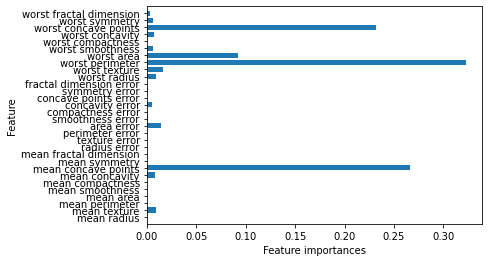

In [21]:
plot_feature_importances_cancer(gbrt_2)

- 트리를 100개나 사용했으므로 깊이가 1이더라도 모든 트리를 분석하기는 쉽지 않음 -> 랜덤 포레스트와가다르게 일부 특성을 강조하고 있음

### 2.3.7 그 외 다른 앙상블
- scikit-learn이 제공하는 다른 앙상블 알고리즘인 **배깅(Bagging), 에이다부스트(AdaBoost), 엑스트라 트리(Extra-Trees), 히스토그램 기반 그레디언트 부스팅(Histogram-based Gradient Boosting) 검토**
- two_moons 데이터 셋과 cancer 데이터 셋 사용

In [22]:
#from preamble import *
from sklearn.datasets import make_moons
from sklearn.datasets import load_breast_cancer

Xm, ym = make_moons(n_samples=100, noise=0.25, random_state=3)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(Xm, ym, stratify=ym, random_state=42)

cancer = load_breast_cancer()
Xc_train, Xc_test, yc_train, yc_test = train_test_split(cancer.data, cancer.target, random_state=0)

#### <U>*배깅*</U>
- Bagging은 Bootstrap aggregating의 줄임말
- 배깅은 중복을 허용한 **랜덤 샘플링으로 만든 훈련 세트를 사용하여 분류기를 각기 다르게 학습** (~랜덤 포레스트 특징과 동일)
- 배깅에 사용하는 분류기가 *predict_proba()* 메서드를 지원하는 경우 확률값을 평균하여 예측 수행, 그 외 분류기를 사용할 때는 가장 빈도가 높은 클래스 레이블로 예측 도출

- **매개변수**
> - ***n_esitimators*** : 생성할 트리의 개수 (기본값 10)
> - 부트스트랩 관련 : ***bootstrap*** (**중복허용여부, 기본값 True-중복허용**), ***max_samples*** (부트스트랩 샘플 개수 지정, 기본 값은 '1'로 훈련 샘플 개수만큼 추출, 원하는 샘플 개수를 지정하거나 훈련 샘플 개수의 비율 0~1사이 지정 가능)
> - **특성 선택(분기 무작위성) : *max_features* (랜덤 포레스트와 달리 기본값 1.0로 전체 특성을 사용), *bootstrap_features* 매개변수(기본값 False)를 True로 지정하면 중복을 허용한 특성을 선택**
> - ***n_jobs***(기본값 1) 매개변수를 이용하여 사용할 코어 수 지정 가능, **-1 설정 시 모든 코어 사용**

In [23]:
# cancer 데이터 셋에 로지스틱 회귀 모델을 100개 훈련하여 앙상블 수행
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
bagging = BaggingClassifier(LogisticRegression(solver='liblinear'), n_estimators=100, oob_score=True,
                            n_jobs=-1, random_state=42)
bagging.fit(Xc_train, yc_train)

BaggingClassifier(base_estimator=LogisticRegression(solver='liblinear'),
                  n_estimators=100, n_jobs=-1, oob_score=True, random_state=42)

- LogisticRegression 객체를 기반 분류기로 전달, 훈련할 분류기의 개수는 100개(***n_estimators*의 기본값은 10**)
- ***oob_score를 True*로 지정(기본값 False)하면 매개변수는 부트스트래핑에 포함되지 않은 샘플을 기반으로 훈련된 모델을 평가**
- *RandomForestClassifier*도 *oob_score* 매개변수를 지원 

In [24]:
print('훈련 세트 정확도: {:.3f}'.format(bagging.score(Xc_train, yc_train)))
print('테스트 세트 정확도: {:.3f}'.format(bagging.score(Xc_test, yc_test)))
print('oob 샘플의 정확도: {:.3f}'.format(bagging.oob_score_))

훈련 세트 정확도: 0.962
테스트 세트 정확도: 0.958
oob 샘플의 정확도: 0.948


> - 결정 트리로 배깅을 수행하는 것보다 랜덤 포레스트를 사용하는 것이 더 편리하나, 여기서는 매개변수 예시로 검토 진행

In [25]:
# two_moons 데이터셋 사용
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
bagging = BaggingClassifier(DecisionTreeClassifier(), n_estimators=5, n_jobs=-1, random_state=42)
bagging.fit(Xm_train, ym_train)

BaggingClassifier(base_estimator=DecisionTreeClassifier(), n_estimators=5,
                  n_jobs=-1, random_state=42)

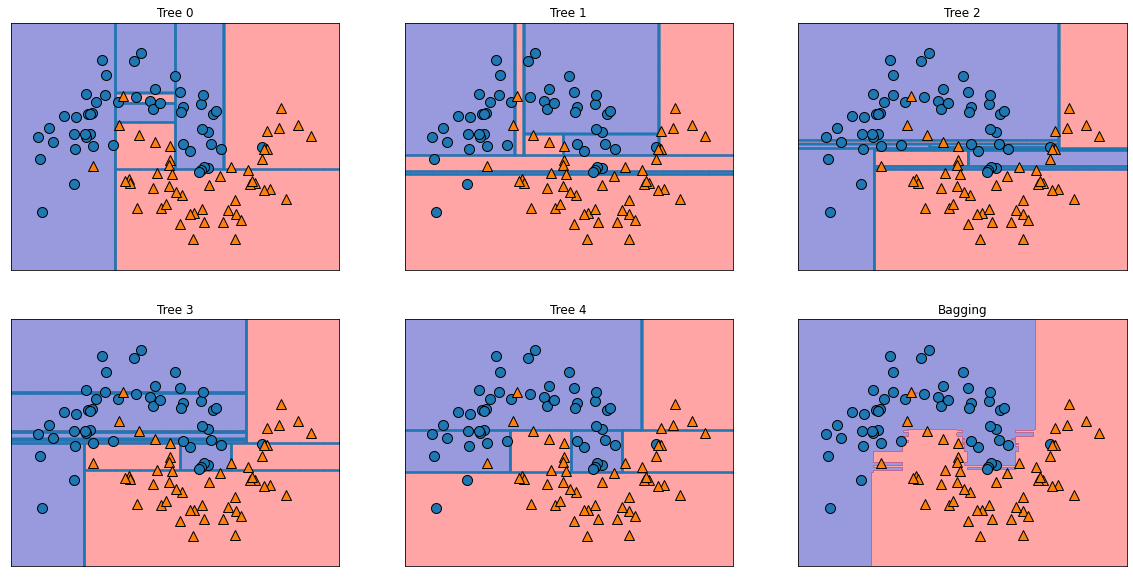

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(20,10))
for i, (ax, tree) in enumerate(zip(axes.ravel(), bagging.estimators_)):
    ax.set_title("Tree {}".format(i))
    mglearn.plots.plot_tree_partition(Xm, ym, tree, ax=ax)

mglearn.plots.plot_2d_separator(bagging, Xm, fill=True, ax=axes[-1,-1], alpha=0.4)
axes[-1,-1].set_title('Bagging')
mglearn.discrete_scatter(Xm[:,0], Xm[:,1], ym)
plt.show()

In [27]:
# cancer 데이터 셋 사용, n_estimators=100
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
bagging = BaggingClassifier(DecisionTreeClassifier(), n_estimators=100,
                            oob_score=True, n_jobs=-1, random_state=42)
bagging.fit(Xc_train, yc_train)

print('훈련 세트 정확도: {:.3f}'.format(bagging.score(Xc_train, yc_train)))
print('테스트 세트 정확도: {:.3f}'.format(bagging.score(Xc_test, yc_test)))
print('OOB 샘플의 정확도: {:.3f}'.format(bagging.oob_score_))

훈련 세트 정확도: 1.000
테스트 세트 정확도: 0.965
OOB 샘플의 정확도: 0.948


> - 랜덤 포레스트는 DecisionTreeClassifier(splitter='best')를 사용하도록 고정, **결정 트리를 splitter='random'으로 설정하면 무작위로 분할한 후보 노드 중에서 최선의 분할을 탐색 -> 엑스트라 트리**

#### <U>*엑스트라 트리*</U>
- 랜덤 포레스트와 비슷하지만 후보 특성을 무작위로 분할한 다음 최적의 분할을 탐색
- **랜덤 포레스트와 달리 DecisionTreeClassifier(splitter='random')을 사용하고 부트스트랩 샘플링은 기본적으로 적용 X**, *bootstrap=True*로 지정하여 부트스트랩 샘플링 사용 가능
- **예측 방식은 랜덤 포레스트와 동일하게 각 트리가 만든 확률값을 평균**
- 랜덤 포레스트와 거의 동일한 성능, 랜덤 포레스트보다 계산 비용이 비교적 적지만 무작위 분할 때문에 일반화 성능을 높이려면 종종 많은 트리 생성이 필요 -> 랜덤 포레스트가 더 선호되는 이유

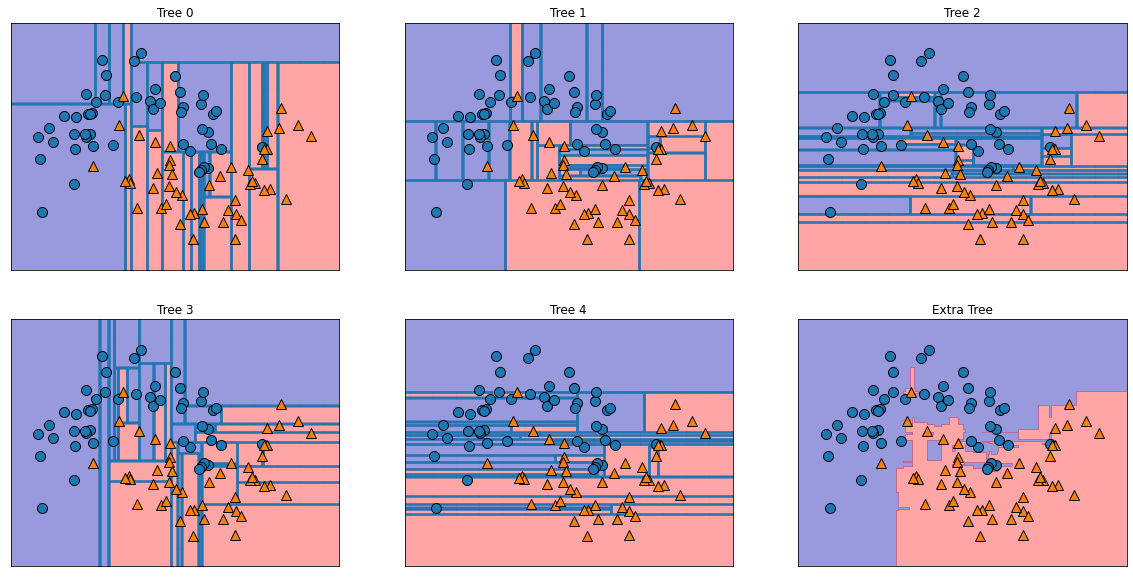

In [28]:
# Two_moons 데이터셋에 엑스트라 트리를 적용하여 결정경계를 확인
from sklearn.ensemble import ExtraTreesClassifier
xtree = ExtraTreesClassifier(n_estimators=5, n_jobs=-1, random_state=0)
xtree.fit(Xm_train, ym_train)

fig, axes = plt.subplots(2, 3, figsize=(20,10))
for i, (ax, tree) in enumerate(zip(axes.ravel(), xtree.estimators_)):
    ax.set_title('Tree {}'.format(i))
    mglearn.plots.plot_tree_partition(Xm, ym, tree, ax=ax)
    
mglearn.plots.plot_2d_separator(xtree, Xm, fill=True, ax=axes[-1,-1], alpha=0.4)
axes[-1,-1].set_title('Extra Tree')
mglearn.discrete_scatter(Xm[:,0], Xm[:,1], ym)
plt.show()

- 후보 노드를 랜덤하게 분할한 다음 최선의 분할을 탐색하기 때문에 개별 트리의 결정 경계가 복잡, 이를 앙상블한 엑스트라 트리의 결정 경계는 비교적 안정적

In [29]:
# 트리 개수를 100으로 지정하여 cancer 데이터셋을 적용 -> 성능이 랜덤 포레스트와 유사하게 도출
xtree = ExtraTreesClassifier(n_estimators=100, n_jobs=-1, random_state=0)
xtree.fit(Xc_train, yc_train)

print('훈련 세트 정확도: {:.3f}'.format(xtree.score(Xc_train, yc_train)))
print('테스트 세트 정확도: {:.3f}'.format(xtree.score(Xc_test, yc_test)))

훈련 세트 정확도: 1.000
테스트 세트 정확도: 0.972


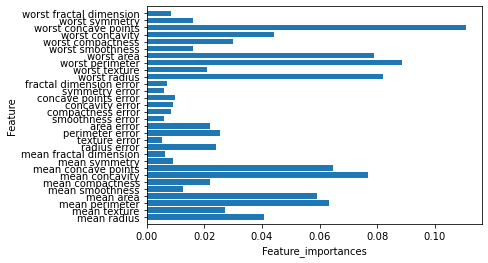

In [30]:
# 특성 중요도 시각화 -> 특성 중요도도 랜덤 포레스트 결과와 유사
n_features = cancer.data.shape[1] # ~ column 개수 
plt.barh(range(n_features), xtree.feature_importances_, align='center')
plt.yticks(np.arange(n_features), cancer.feature_names)
plt.xlabel('Feature_importances')
plt.ylabel('Feature')
plt.ylim(-1, n_features)
plt.show()

#### <U>*에이다 부스트*</U>
- Adaptive Boosting, 그레디언트 부스팅처럼 약한 학습기를 사용
- 그레디언트 부스팅과는 달리 **이전의 모델이 잘못 분류한 샘플에 가중치를 높여서 다음 모델을 훈련** -> 순차적 학습, *n_jobs* 미지원
- **예측 방식은 모델이 예측한 레이블을 기준으로 모델의 가중치를 합산하여 가장 높은 값을 가지는 레이블을 선택**
- 기본적으로 분류의 경우 DecisionTreeClassifier(max_depth=1), 회귀의 경우 DecisionTreeRegressor(max_depth=3)을 사용하지만 ***base_estimator* 매개변수에서 다른 모델을 지정할 수 있음**

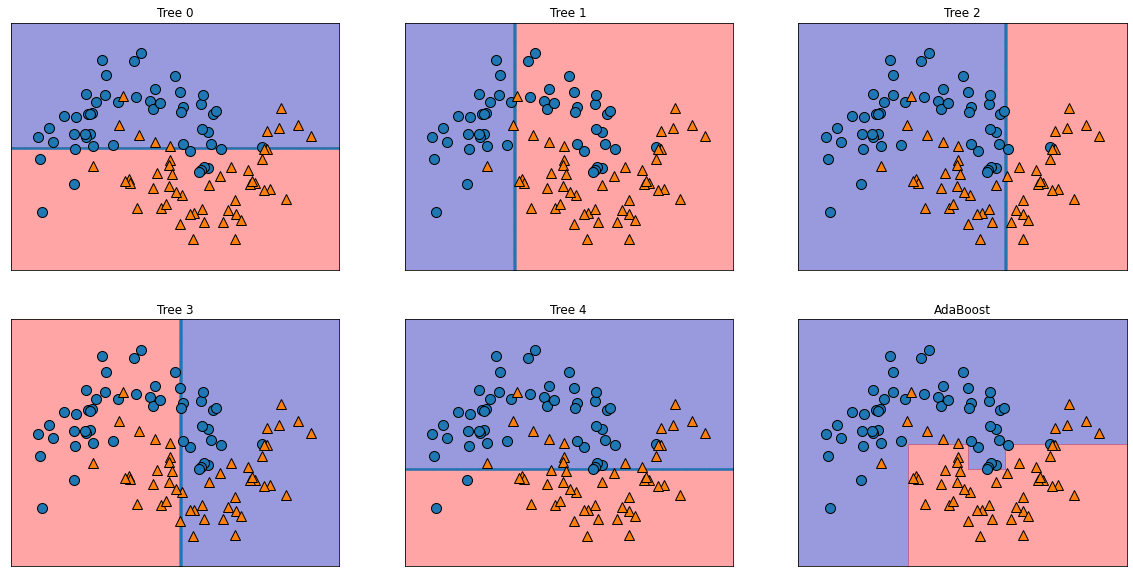

In [31]:
# Two_Moons 데이터셋에 적용하여 결정 경계 확인
from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier(n_estimators=5, random_state=42)
ada.fit(Xm_train, ym_train)

fig, axes = plt.subplots(2,3, figsize=(20,10))
for i, (ax, tree) in enumerate(zip(axes.ravel(), ada.estimators_)):
    ax.set_title('Tree {}'.format(i))
    mglearn.plots.plot_tree_partition(Xm, ym, tree, ax=ax)
    
mglearn.plots.plot_2d_separator(ada, Xm, fill=True, ax=axes[-1,-1], alpha=0.4)
axes[-1,-1].set_title('AdaBoost')
mglearn.discrete_scatter(Xm[:,0], Xm[:,1], ym)
plt.show()

- AdaBoostClassifier는 깊이 1인 결정 트리를 사용하기 때문에 각 트리의 결정 경계가 직선 하나
- 앙상블된 결정 경계도 다른 앙상블 모델에 비해 조금 더 단순화

In [32]:
# Cancer 데이터셋에 AdaBoost 적용
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(Xc_train, yc_train)

print('훈련 세트 정확도: {:.3f}'.format(ada.score(Xc_train, yc_train)))
print('테스트 세트 정확도: {:.3f}'.format(ada.score(Xc_test, yc_test)))

훈련 세트 정확도: 1.000
테스트 세트 정확도: 0.986


- 얕은 트리를 앙상블 했으므로 일반화 성능이 조금 더 향상된 결과를 보임

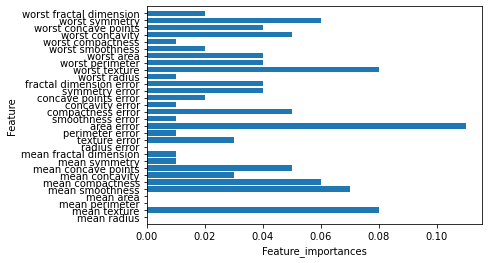

In [33]:
# Cancer 데이터셋에 대한 특성 중요도
plt.barh(range(n_features), ada.feature_importances_, align='center')
plt.yticks(np.arange(n_features), cancer.feature_names)
plt.xlabel('Feature_importances')
plt.ylabel('Feature')
plt.ylim(-1, n_features)
plt.show()

- 다른 모델에서 부각되지 않았던 'area error' 특성을 크게 강조

#### <U>*히스토그램 기반 부스팅*</U>
- **입력 특성을 256개의 구간으로 나누기 때문에 노드를 분할할 때 최적의 분할을 빠르게 탐색**
- 256 구간 중 하나를 누락된 값을 위해서 사용하기 때문에 **누락된 값을 위해 전처리 필요 없음**
- 일반적으로 샘플 개수가 1만 개보다 많은 경우 그레디언트 부스팅보다 속도가 빠름
- 기본 매개변수에서도 비교적 좋은 성능을 제공하며, 성능을 높이기 위해 부스팅 횟수(트리개수)를 지정하는 ***max_iter* (기본값 100) 값을 증가**
- **히스토그램 기반 부스팅은 특성 중요도를 따로 제공하지 않음 -> 대신 *permutation_importance* 함수 사용**

- ***permutation_importance 함수***
> - 특성 값을 차례대로 섞은 후 모델의 성능을 평가하여 어떤 특성이 중요한 역할을 하는지 계산
> - 해당 함수는 히스토그램 기반 부스팅뿐만 아니라 scikit-learn의 다른 모델에 모두 사용 가능

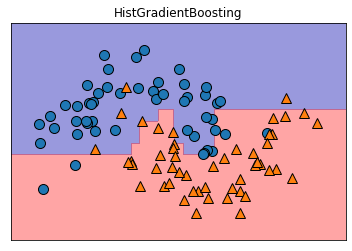

In [34]:
# Two_Moons 데이터셋에 적용하여 결정 경계 확인
from sklearn.ensemble import HistGradientBoostingClassifier
hgb = HistGradientBoostingClassifier(random_state=42)
hgb.fit(Xm_train, ym_train)

mglearn.plots.plot_2d_separator(hgb, Xm, fill=True, alpha=0.4)
plt.title('HistGradientBoosting')
mglearn.discrete_scatter(Xm[:,0], Xm[:,1], ym)
plt.show()

- 비교적 결정 경계가 복잡하지 않으면서도 중앙 부분에 섞인 두 클래스를 잘 나누고 있음

In [35]:
# cancer 데이터셋에 적용
hgb = HistGradientBoostingClassifier(random_state=42)
hgb.fit(Xc_train, yc_train)

print('훈련 세트 정확도: {:.3f}'.format(hgb.score(Xc_train, yc_train)))
print('테스트 세트 정확도: {:.3f}'.format(hgb.score(Xc_test, yc_test)))

훈련 세트 정확도: 1.000
테스트 세트 정확도: 0.979


- 에이다부스트보다는 낮지만 다른 앙상블 방법보다 좋은 결과를 제공

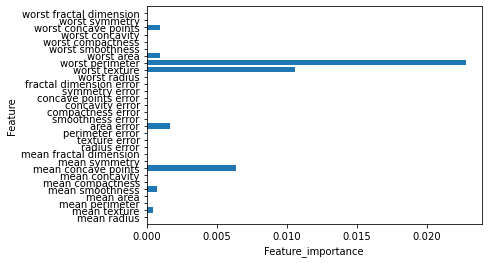

In [36]:
# cancer 데이터셋에서 훈련한 HistGradientBoostingClassifier에서 10번씩 특성을 섞어서 특성 중요도를 출력하는 코드
from sklearn.inspection import permutation_importance

result = permutation_importance(hgb, Xc_train, yc_train,
                                n_repeats=10, random_state=42, n_jobs=-1)

plt.barh(range(n_features), result.importances_mean, align='center')
plt.yticks(np.arange(n_features), cancer.feature_names)
plt.xlabel('Feature_importance')
plt.ylabel('Feature')
plt.ylim(-1, n_features)
plt.show()

- 그레디언트 부스팅과 비슷하게 일부 특성에 크게 의존, 특히 'worst perimeter'

> - **교재 143 페이지 표: "트리 기반 앙상블 모델의 매개변수 기본값 비교"** 삽입하기